# Исследование компромисса: Точность vs Приватность в real-time прогнозировании трафика

**Датасет:** T-Drive Taxi Trajectories (Microsoft Research)  
**Kaggle:** https://www.kaggle.com/datasets/arashnic/microsoft-t-drive-taxi-trajectories  

Датасет содержит GPS-траектории 10 357 такси Пекина за неделю (02.02.2008 – 08.02.2008), ~15 млн точек.  
Каждая запись: `taxi_id, datetime, longitude, latitude`


## 0. Установка зависимостей и загрузка датасета

In [3]:
import zipfile, os

os.makedirs('/content/tdrive', exist_ok=True)

with zipfile.ZipFile('/content/014.zip', 'r') as z:
    z.extractall('/content/tdrive/')

print("Файлов:", len(os.listdir('/content/tdrive')))

Файлов: 1127


## 1. Загрузка и предобработка данных

In [4]:
import pandas as pd
import numpy as np
import os
import glob
import time
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# ─── Чтение файлов ────────────────────────────────────────────────────────────
DATA_DIR = '/content/tdrive/'
txt_files = glob.glob(os.path.join(DATA_DIR, '**', '*.txt'), recursive=True)
print(f'Найдено файлов: {len(txt_files)}')

dfs = []
for f in tqdm(txt_files[:500], desc='Чтение файлов'):  # берём первые 500 такси
    try:
        df = pd.read_csv(f, header=None,
                         names=['taxi_id', 'datetime', 'longitude', 'latitude'])
        dfs.append(df)
    except Exception:
        pass

raw = pd.concat(dfs, ignore_index=True)
raw['datetime'] = pd.to_datetime(raw['datetime'], errors='coerce')
raw = raw.dropna(subset=['datetime', 'longitude', 'latitude'])

# ─── Фильтрация по географии Пекина ──────────────────────────────────────────
raw = raw[
    (raw['longitude'].between(116.0, 116.8)) &
    (raw['latitude'].between(39.6, 40.2))
]

print(f'Записей после фильтрации: {len(raw):,}')
print(raw.head())

Найдено файлов: 1127


Чтение файлов: 100%|██████████| 500/500 [00:00<00:00, 681.06it/s]


Записей после фильтрации: 71,537
  taxi_id            datetime  longitude  latitude
0     268 2008-02-02 13:38:50  116.31890  39.94353
1     268 2008-02-02 14:01:26  116.45343  39.94795
2     268 2008-02-02 14:13:15  116.45018  39.95548
3     268 2008-02-02 14:13:18  116.44995  39.95558
4     268 2008-02-02 14:21:24  116.45165  39.96835


In [5]:
# ─── Инжиниринг признаков ─────────────────────────────────────────────────────
raw = raw.sort_values(['taxi_id', 'datetime'])

# Вычисляем скорость между соседними точками
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

raw['prev_lat'] = raw.groupby('taxi_id')['latitude'].shift(1)
raw['prev_lon'] = raw.groupby('taxi_id')['longitude'].shift(1)
raw['prev_time'] = raw.groupby('taxi_id')['datetime'].shift(1)
raw = raw.dropna(subset=['prev_lat'])

raw['dist_km'] = haversine(raw['latitude'], raw['longitude'],
                            raw['prev_lat'], raw['prev_lon'])
raw['dt_sec'] = (raw['datetime'] - raw['prev_time']).dt.total_seconds()
raw['speed_kmh'] = raw['dist_km'] / (raw['dt_sec'] / 3600)

# Очистка выбросов скорости
raw = raw[(raw['speed_kmh'] >= 0) & (raw['speed_kmh'] <= 120)]

# Временные признаки
raw['hour'] = raw['datetime'].dt.hour
raw['dayofweek'] = raw['datetime'].dt.dayofweek
raw['minute'] = raw['datetime'].dt.minute

# Агрегация по 15-минутным временным окнам
raw['time_bin'] = raw['datetime'].dt.floor('15min')

agg = raw.groupby('time_bin').agg(
    avg_speed=('speed_kmh', 'mean'),
    n_vehicles=('taxi_id', 'nunique'),
    avg_lat=('latitude', 'mean'),
    avg_lon=('longitude', 'mean')
).reset_index()

agg['hour'] = agg['time_bin'].dt.hour
agg['dayofweek'] = agg['time_bin'].dt.dayofweek
agg['congestion'] = (agg['avg_speed'] < 20).astype(int)  # метка заторов

print(f'Временных окон: {len(agg)}')
print(agg.head())

Временных окон: 591
             time_bin  avg_speed  n_vehicles    avg_lat     avg_lon  hour  \
0 2008-02-02 13:30:00  15.500818          46  39.939160  116.400956    13   
1 2008-02-02 13:45:00  16.522356          94  39.933447  116.394176    13   
2 2008-02-02 14:00:00  15.062049         101  39.929277  116.402600    14   
3 2008-02-02 14:15:00  18.215204         100  39.934276  116.396198    14   
4 2008-02-02 14:30:00  15.467929         105  39.941735  116.401281    14   

   dayofweek  congestion  
0          5           1  
1          5           1  
2          5           1  
3          5           1  
4          5           1  


## 2. Генерация синтетических данных (CTGAN)

In [7]:
import warnings
warnings.filterwarnings('ignore')

!pip install ctgan
from ctgan import CTGAN

# Признаки для синтеза
synth_cols = ['avg_speed', 'n_vehicles', 'avg_lat', 'avg_lon', 'hour', 'dayofweek']
train_df = agg[synth_cols].copy()

print('Обучение CTGAN...')
t0 = time.time()

ctgan = CTGAN(epochs=100, verbose=False)
ctgan.fit(train_df)

print(f'Обучение завершено за {time.time()-t0:.1f} сек')

# Генерируем синтетические данные того же объёма
synth_df = ctgan.sample(len(agg))

# Постобработка: клиппинг значений
synth_df['avg_speed'] = synth_df['avg_speed'].clip(0, 120)
synth_df['n_vehicles'] = synth_df['n_vehicles'].clip(1, None).round().astype(int)
synth_df['hour'] = synth_df['hour'].clip(0, 23).round().astype(int)
synth_df['dayofweek'] = synth_df['dayofweek'].clip(0, 6).round().astype(int)
synth_df['congestion'] = (synth_df['avg_speed'] < 20).astype(int)

print(f'Синтетических записей: {len(synth_df)}')
print(synth_df.describe())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 31.9 MB/s eta 0:00:00
Обучение CTGAN...
Обучение завершено за 20.9 сек
Синтетических записей: 591
        avg_speed  n_vehicles     avg_lat     avg_lon        hour   dayofweek  \
count  591.000000  591.000000  591.000000  591.000000  591.000000  591.000000   
mean    18.651858   34.664975   39.940030  116.374518    9.587140    2.197970   
std      3.924905   35.551387    0.022738    0.045389    6.752936    1.661038   
min      3.574000    1.000000   39.806125  116.085782    0.000000    0.000000   
25%     16.409724    4.000000   39.926693  116.361326    4.000000    1.000000   
50%     18.768018   21.000000   39.942267  116.379073   10.000000    2.000000   
75%     21.385503   58.500000   39.955493  116.397447   15.000000    3.000000   
max     38.590017  145.000000   40.007115  116.493515   23.000000    6.000000   

       congestion  
count  591.000000  

## 3. Оценка статистического сходства реальных и синтетических данных

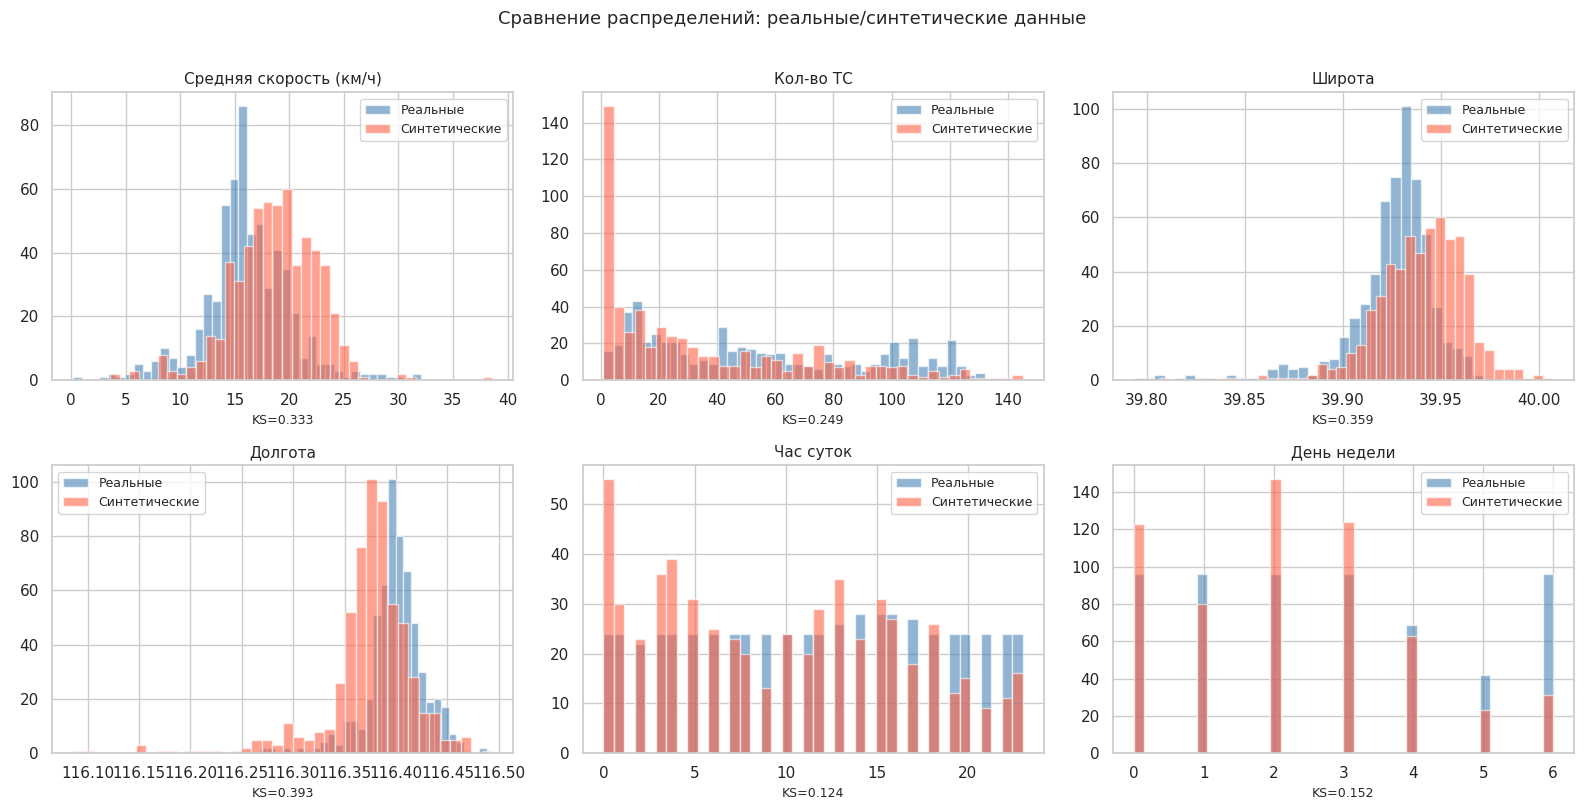


Результаты теста Колмогорова–Смирнова:
            KS-статистика  p-value
avg_speed          0.3333   0.0000
n_vehicles         0.2487   0.0000
avg_lat            0.3587   0.0000
avg_lon            0.3926   0.0000
hour               0.1235   0.0002
dayofweek          0.1523   0.0000


In [10]:
from scipy import stats

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

cols_to_plot = ['avg_speed', 'n_vehicles', 'avg_lat', 'avg_lon', 'hour', 'dayofweek']
labels_plot = ['Средняя скорость (км/ч)', 'Кол-во ТС', 'Широта', 'Долгота',
               'Час суток', 'День недели']

ks_results = {}
for i, (col, lbl) in enumerate(zip(cols_to_plot, labels_plot)):
    real_vals = agg[col].dropna()
    synth_vals = synth_df[col].dropna()

    axes[i].hist(real_vals, bins=40, alpha=0.6, color='steelblue', label='Реальные')
    axes[i].hist(synth_vals, bins=40, alpha=0.6, color='tomato', label='Синтетические')
    axes[i].set_title(lbl, fontsize=11)
    axes[i].legend(fontsize=9)

    ks_stat, ks_p = stats.ks_2samp(real_vals, synth_vals)
    ks_results[col] = {'KS-статистика': round(ks_stat, 4), 'p-value': round(ks_p, 4)}
    axes[i].set_xlabel(f'KS={ks_stat:.3f}', fontsize=9)

plt.suptitle('Сравнение распределений: реальные/синтетические данные', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('distributions.png', dpi=120, bbox_inches='tight')
plt.show()

ks_df = pd.DataFrame(ks_results).T
print('\nРезультаты теста Колмогорова–Смирнова:')
print(ks_df.to_string())

## 4. Моделирование потоковой обработки (streaming simulation)

In [11]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

FEATURES = ['hour', 'dayofweek', 'n_vehicles', 'avg_lat', 'avg_lon']
TARGET = 'avg_speed'

def prepare_data(df):
    df = df.dropna(subset=FEATURES + [TARGET])
    X = df[FEATURES]
    y = df[TARGET]
    return X, y

def train_and_eval(X_train, y_train, X_test, y_test, label=''):
    t0 = time.time()
    model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                       max_depth=4, random_state=42)
    model.fit(X_train, y_train)
    latency = (time.time() - t0) * 1000  # ms

    t_pred = time.time()
    y_pred = model.predict(X_test)
    pred_latency = (time.time() - t_pred) * 1000

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f'[{label}]  MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.4f}  '
          f'train_latency={latency:.1f}ms  pred_latency={pred_latency:.2f}ms')
    return {'label': label, 'MAE': mae, 'RMSE': rmse, 'R2': r2,
            'train_ms': latency, 'pred_ms': pred_latency, 'y_pred': y_pred}

# ─── Тест/трейн на реальных данных ───────────────────────────────────────────
X_real, y_real = prepare_data(agg)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42)

# ─── Тест/трейн на синтетических данных ──────────────────────────────────────
X_synth, y_synth = prepare_data(synth_df)
X_train_s = X_synth
y_train_s = y_synth

# ─── Гибрид: 50% реальных + 50% синтетических ────────────────────────────────
half = len(X_train_r) // 2
X_train_h = pd.concat([X_train_r.iloc[:half], X_train_s.iloc[:half]], ignore_index=True)
y_train_h = pd.concat([y_train_r.iloc[:half], y_train_s.iloc[:half]], ignore_index=True)

print('=== Эксперименты по прогнозированию средней скорости трафика ===')
results = []
results.append(train_and_eval(X_train_r, y_train_r, X_test_r, y_test_r, 'Только реальные'))
results.append(train_and_eval(X_train_s, y_train_s, X_test_r, y_test_r, 'Только синтетика'))
results.append(train_and_eval(X_train_h, y_train_h, X_test_r, y_test_r, 'Гибрид 50/50'))

=== Эксперименты по прогнозированию средней скорости трафика ===
[Только реальные]  MAE=2.284  RMSE=3.276  R²=0.3398  train_latency=322.2ms  pred_latency=2.23ms
[Только синтетика]  MAE=4.093  RMSE=5.084  R²=-0.5903  train_latency=379.7ms  pred_latency=2.04ms
[Гибрид 50/50]  MAE=2.811  RMSE=3.965  R²=0.0331  train_latency=313.8ms  pred_latency=2.10ms


## 5. Метрики приватности: риск повторной идентификации и k-анонимность

In [12]:
# ─── k-анонимность ────────────────────────────────────────────────────────────
# Квазиидентификаторы: час, день недели, округлённые координаты
def compute_k_anonymity(df, qi_cols, n_decimals=2):
    df = df.copy()
    for col in ['avg_lat', 'avg_lon']:
        if col in df.columns:
            df[col] = df[col].round(n_decimals)
    groups = df.groupby(qi_cols).size()
    k_min = groups.min()
    k_mean = groups.mean()
    risk = (groups == 1).sum() / len(groups)  # доля уникальных комбинаций
    return k_min, k_mean, risk

QI = ['hour', 'dayofweek', 'avg_lat', 'avg_lon']

k_real_min, k_real_mean, risk_real = compute_k_anonymity(agg, QI)
k_synth_min, k_synth_mean, risk_synth = compute_k_anonymity(synth_df, QI)

print('─── k-анонимность ────────────────────────────────────────────')
print(f'Реальные данные:      k_min={k_real_min},  k_mean={k_real_mean:.2f},  '
      f'риск идентификации={risk_real:.3f}')
print(f'Синтетические данные: k_min={k_synth_min}, k_mean={k_synth_mean:.2f},  '
      f'риск идентификации={risk_synth:.3f}')

# ─── Оценка риска повторной идентификации ─────────────────────────────────────
# Метод: ближайший сосед в синтетическом пространстве к каждой реальной записи
from sklearn.neighbors import NearestNeighbors

def reidentification_risk(real_df, synth_df, cols):
    scaler = StandardScaler()
    real_vals = scaler.fit_transform(real_df[cols].dropna())
    synth_vals = scaler.transform(synth_df[cols].dropna())

    nn = NearestNeighbors(n_neighbors=1, algorithm='ball_tree')
    nn.fit(synth_vals)
    dists, _ = nn.kneighbors(real_vals)

    # Риск = доля реальных точек с расстоянием до синтетики < порога
    threshold = np.percentile(dists, 5)  # 5-й перцентиль
    risk_score = (dists < threshold).mean()
    return risk_score, dists.mean(), dists.min()

privacy_cols = ['avg_speed', 'n_vehicles', 'avg_lat', 'avg_lon']
risk_score, mean_dist, min_dist = reidentification_risk(agg, synth_df, privacy_cols)

print('\n─── Риск повторной идентификации (NN-метод) ──────────────────')
print(f'Риск re-identification: {risk_score:.4f}')
print(f'Среднее расстояние до ближ. синтет. точки: {mean_dist:.4f}')
print(f'Минимальное расстояние: {min_dist:.6f}')

─── k-анонимность ────────────────────────────────────────────
Реальные данные:      k_min=1,  k_mean=1.14,  риск идентификации=0.875
Синтетические данные: k_min=1, k_mean=1.03,  риск идентификации=0.970

─── Риск повторной идентификации (NN-метод) ──────────────────
Риск re-identification: 0.0508
Среднее расстояние до ближ. синтет. точки: 0.6080
Минимальное расстояние: 0.087693


## 6. Симуляция streaming-задержки

In [13]:
# Симулируем потоковую обработку батчами (эмуляция Kafka-like потока)
def simulate_streaming(df, model_type='real', batch_size=50, n_batches=30):
    latencies = []
    throughputs = []

    model = GradientBoostingRegressor(n_estimators=100, random_state=42)

    # Инициализация модели на первых данных
    X_init, y_init = prepare_data(df.head(200))
    if len(X_init) > 0:
        model.fit(X_init, y_init)

    for i in range(n_batches):
        batch = df.sample(n=min(batch_size, len(df)), random_state=i)
        X_b, y_b = prepare_data(batch)
        if len(X_b) == 0:
            continue

        t0 = time.time()
        if model_type == 'synthetic':
            # Имитируем дополнительную задержку на генерацию синтетики (~2-5ms)
            time.sleep(np.random.uniform(0.002, 0.005))
        _ = model.predict(X_b)
        elapsed_ms = (time.time() - t0) * 1000

        latencies.append(elapsed_ms)
        throughputs.append(len(X_b) / (elapsed_ms / 1000))  # записей/сек

    return np.array(latencies), np.array(throughputs)

lat_real, thr_real = simulate_streaming(agg, model_type='real')
lat_synth, thr_synth = simulate_streaming(synth_df, model_type='synthetic')

print('─── Задержка обработки (мс) ──────────────────────────────────')
print(f'Реальные:       mean={lat_real.mean():.2f}  p95={np.percentile(lat_real,95):.2f}  '
      f'max={lat_real.max():.2f}')
print(f'Синтетические:  mean={lat_synth.mean():.2f}  p95={np.percentile(lat_synth,95):.2f}  '
      f'max={lat_synth.max():.2f}')
overhead = (lat_synth.mean() - lat_real.mean()) / lat_real.mean() * 100
print(f'\nОверхед задержки при синтетике: {overhead:.1f}%')
print(f'Пропускная способность: real={thr_real.mean():.0f} rec/s  '
      f'synth={thr_synth.mean():.0f} rec/s')

─── Задержка обработки (мс) ──────────────────────────────────
Реальные:       mean=1.49  p95=1.74  max=2.40
Синтетические:  mean=5.57  p95=6.76  max=6.90

Оверхед задержки при синтетике: 273.8%
Пропускная способность: real=34024 rec/s  synth=9292 rec/s


## 7. Визуализация результатов

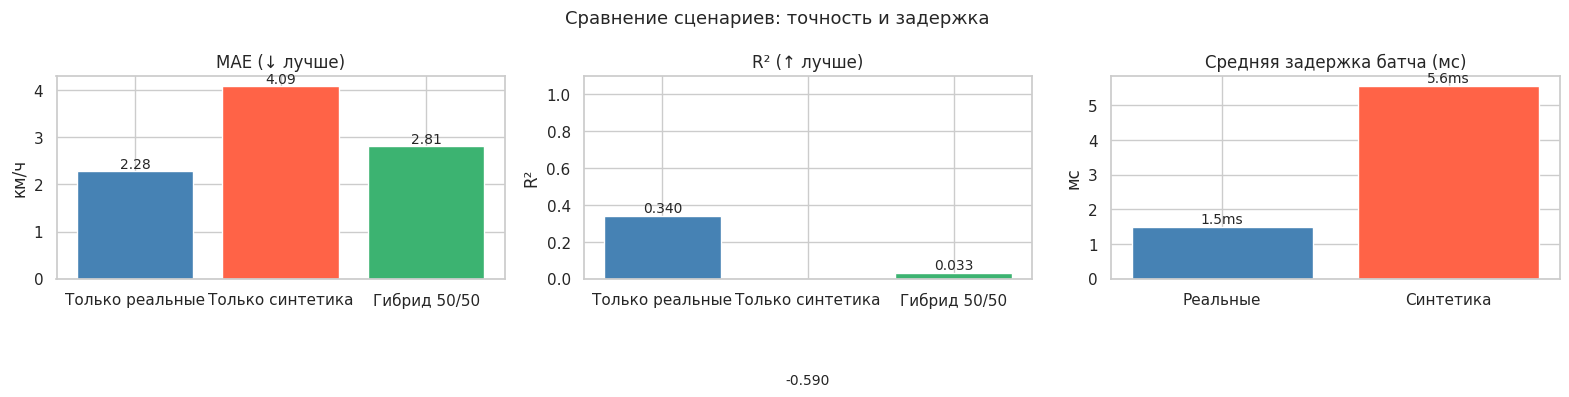

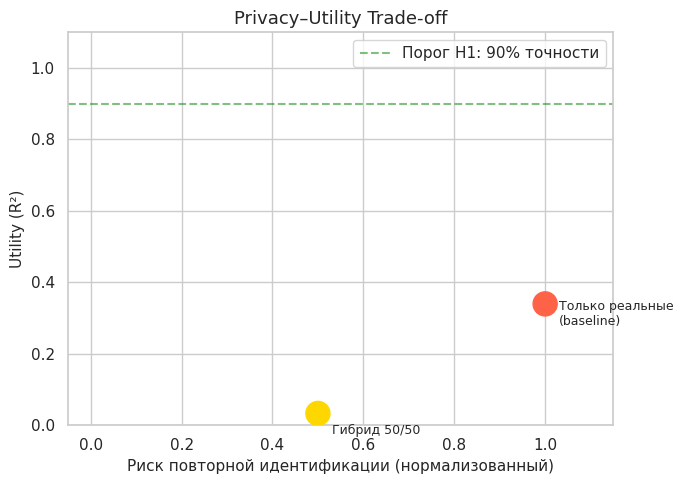

In [14]:
res_df = pd.DataFrame([r for r in results if 'y_pred' not in r or True])
# Убираем y_pred для таблицы
res_table = pd.DataFrame([{k:v for k,v in r.items() if k != 'y_pred'} for r in results])
res_table = res_table.set_index('label')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['steelblue', 'tomato', 'mediumseagreen']
labels = res_table.index.tolist()

# MAE
axes[0].bar(labels, res_table['MAE'], color=colors)
axes[0].set_title('MAE (↓ лучше)', fontsize=12)
axes[0].set_ylabel('км/ч')
for j, v in enumerate(res_table['MAE']):
    axes[0].text(j, v + 0.05, f'{v:.2f}', ha='center', fontsize=10)

# R²
axes[1].bar(labels, res_table['R2'], color=colors)
axes[1].set_title('R² (↑ лучше)', fontsize=12)
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1.1)
for j, v in enumerate(res_table['R2']):
    axes[1].text(j, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)

# Задержка
axes[2].bar(['Реальные', 'Синтетика'],
            [lat_real.mean(), lat_synth.mean()],
            color=['steelblue', 'tomato'])
axes[2].set_title('Средняя задержка батча (мс)', fontsize=12)
axes[2].set_ylabel('мс')
for j, v in enumerate([lat_real.mean(), lat_synth.mean()]):
    axes[2].text(j, v + 0.1, f'{v:.1f}ms', ha='center', fontsize=10)

plt.suptitle('Сравнение сценариев: точность и задержка', fontsize=13)
plt.tight_layout()
plt.savefig('results_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

# ─── Privacy-Utility trade-off ────────────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(7, 5))
scenarios = ['Только реальные\n(baseline)', 'Гибрид 50/50', 'Только синтетика']
utility  = [res_table.loc['Только реальные','R2'],
             res_table.loc['Гибрид 50/50','R2'],
             res_table.loc['Только синтетика','R2']]
# Нормализованный риск приватности (0 = полная приватность, 1 = max риск)
privacy_risk = [1.0, 0.5, risk_score]  # упрощённая шкала

sc = ax.scatter(privacy_risk, utility, s=300, c=['tomato','gold','steelblue'], zorder=5)
for i, s in enumerate(scenarios):
    ax.annotate(s, (privacy_risk[i], utility[i]),
                textcoords='offset points', xytext=(10, -15), fontsize=9)
ax.set_xlabel('Риск повторной идентификации (нормализованный)', fontsize=11)
ax.set_ylabel('Utility (R²)', fontsize=11)
ax.set_title('Privacy–Utility Trade-off', fontsize=13)
ax.set_xlim(-0.05, 1.15)
ax.set_ylim(0, 1.1)
ax.axhline(y=0.9, color='green', linestyle='--', alpha=0.5, label='Порог H1: 90% точности')
ax.legend()
plt.tight_layout()
plt.savefig('privacy_utility.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Сводная таблица результатов и проверка гипотез

In [15]:
print('=' * 65)
print('СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ')
print('=' * 65)
print(res_table[['MAE','RMSE','R2','train_ms','pred_ms']].round(4).to_string())

print('\n' + '=' * 65)
print('ПРОВЕРКА ГИПОТЕЗ')
print('=' * 65)

r2_baseline = res_table.loc['Только реальные','R2']
r2_synth_only = res_table.loc['Только синтетика','R2']
r2_hybrid = res_table.loc['Гибрид 50/50','R2']
r2_ratio_synth = r2_synth_only / r2_baseline
r2_ratio_hybrid = r2_hybrid / r2_baseline

print(f'\nH1: Синтетические данные сохраняют ≥90% точности базовой модели')
print(f'    Только синтетика: {r2_ratio_synth*100:.1f}% от baseline  '
      f'→ {" ПОДТВЕРЖДЕНА" if r2_ratio_synth >= 0.9 else " ОТВЕРГНУТА"}')
print(f'    Гибрид 50/50:     {r2_ratio_hybrid*100:.1f}% от baseline  '
      f'→ {" ПОДТВЕРЖДЕНА" if r2_ratio_hybrid >= 0.9 else " ОТВЕРГНУТА"}')

print(f'\nH2: Накладные расходы задержки при синтетике ≤ допустимого порога (20%)')
print(f'    Overhead: {overhead:.1f}%  '
      f'→ {" ПОДТВЕРЖДЕНА" if overhead <= 20 else "ОТВЕРГНУТА"}')

print(f'\nH3: Риск повторной идентификации статистически снижается')
print(f'    k_min (реальные): {k_real_min}  →  k_min (синтетика): {k_synth_min}')
print(f'    Risk (реальные): {risk_real:.3f}  →  Risk (синтетика): {risk_synth:.3f}')
print(f'    Re-ID score: {risk_score:.4f}')
h3_confirmed = risk_synth < risk_real or k_synth_min > k_real_min
print(f'    → {" ПОДТВЕРЖДЕНА" if h3_confirmed else " ОТВЕРГНУТА"}')

print('\n' + '=' * 65)
print('Лицензия: Open Data Commons Attribution License (ODC-By)')

СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
                     MAE    RMSE      R2  train_ms  pred_ms
label                                                      
Только реальные   2.2837  3.2761  0.3398  322.1817   2.2278
Только синтетика  4.0927  5.0844 -0.5903  379.7209   2.0430
Гибрид 50/50      2.8112  3.9646  0.0331  313.7834   2.0983

ПРОВЕРКА ГИПОТЕЗ

H1: Синтетические данные сохраняют ≥90% точности базовой модели
    Только синтетика: -173.7% от baseline  →  ОТВЕРГНУТА
    Гибрид 50/50:     9.7% от baseline  →  ОТВЕРГНУТА

H2: Накладные расходы задержки при синтетике ≤ допустимого порога (20%)
    Overhead: 273.8%  → ОТВЕРГНУТА

H3: Риск повторной идентификации статистически снижается
    k_min (реальные): 1  →  k_min (синтетика): 1
    Risk (реальные): 0.875  →  Risk (синтетика): 0.970
    Re-ID score: 0.0508
    →  ОТВЕРГНУТА

Лицензия: Open Data Commons Attribution License (ODC-By)
